First 10 rows of the DataFrame:


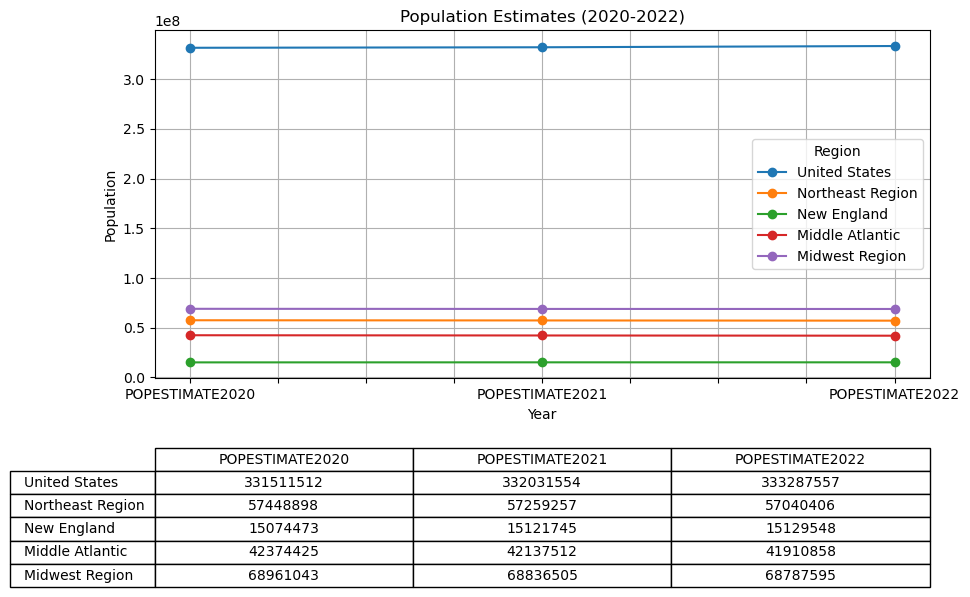

In [10]:

#Creating a DataFrame from a URL and display the first 10 rows
#This task requires loading data from a CSV file hosted online, so I'll need to write code.

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats # Import the stats module from SciPy

# URL of the CSV file
url = 'https://gist.githubusercontent.com/mattkram/d3880a3a23ca36ccf10f22c1f49adb29/raw/f4602d2b9a17eb0d17355897264f4bad80c5528f/NST-EST2022-POPCHG2020_2022.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(url)

# Display the first 10 rows
print("First 10 rows of the DataFrame:")
df.head(10)

cols_to_plot = ['NAME', 'POPESTIMATE2020', 'POPESTIMATE2021', 'POPESTIMATE2022']
plot_df = df[cols_to_plot].head(5)

# 2. Set 'NAME' as the index so it appears in the legend
plot_df.set_index('NAME', inplace=True)

# 3. Transpose the DataFrame so that the Years become the X-axis
plot_chart = plot_df.T

# 4. Create the line plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_chart.plot(ax=ax , marker='o')

table_data = plot_df

table = plt.table(cellText=table_data.values,
                  rowLabels=table_data.index,
                  colLabels=table_data.columns,
                  cellLoc='center', 
                  loc='bottom', 
                  bbox=[0.0, -0.6, 1.0, 0.4]) # [x, y, width, height]

plt.subplots_adjust(bottom=0.3)

# Add titles and labels
plt.title('Population Estimates (2020-2022)')
plt.ylabel('Population')
plt.xlabel('Year')
plt.grid(True)
plt.legend(title='Region')
plt.show()





In [12]:
# 1. Calculate the percentage change from 2020 to 2022
# Formula: ((2022 Estimate - 2020 Estimate) / 2020 Estimate) * 100
df['POP_PCT_CHANGE'] = (df['POPESTIMATE2022'] - df['POPESTIMATE2020']) / df['POPESTIMATE2020'] * 100

# 2. Filter the DataFrame to include only states (SUMLEV == 40)
# The states are the most interesting units for growth analysis.
state_df = df[df['SUMLEV'] == 40].copy()

# 3. Display the top 10 states by percentage growth
print("Top 10 States by Percentage Population Growth (2020-2022):")
print("-" * 60)
print(state_df.sort_values(by='POP_PCT_CHANGE', ascending=False)[['NAME', 'POP_PCT_CHANGE']].head(10))

Top 10 States by Percentage Population Growth (2020-2022):
------------------------------------------------------------
              NAME  POP_PCT_CHANGE
26           Idaho        4.857825
40         Montana        3.292505
23         Florida        3.034892
58            Utah        2.954365
54  South Carolina        2.938240
57           Texas        2.726755
21        Delaware        2.649091
16         Arizona        2.496594
55    South Dakota        2.480854
47  North Carolina        2.387955
